In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Data imports #

# Imports for plot c
s_profs=np.load('s.npy',allow_pickle=True) # this is s not rho
omega_zetas=np.load('freq.npy',allow_pickle=True)

# Imports for Poincares
etas_all_KE0 = np.load('poinc_0_etas.npy',allow_pickle=True)
etas_all_KE1 = np.load('poinc_1_etas.npy',allow_pickle=True)
s_all_KE0 = np.load('poinc_0_s.npy',allow_pickle=True)
s_all_KE1 = np.load('poinc_1_s.npy',allow_pickle=True)

etas_all = [etas_all_KE0,etas_all_KE1]
s_all = [s_all_KE0,s_all_KE1]

In [3]:
# Resonance stuff #

# Rational numbers
p_max=4
q_max=4
res_range_min = -2
res_range_max = 2
res_arr = np.array([])
# q_arr = np.array([])
res_arr_set = 0

# including the zero resonance
res_arr = np.append(res_arr,0)

for p in range(1,p_max+1): # include the zero resonance
    for q in range(1,q_max+1):
            condition1 = p/q >= res_range_min and p/q <= res_range_max
            if ~np.isin(p/q, res_arr) and condition1:
                res_arr = np.append(res_arr,p/q)
                res_arr = np.append(res_arr,-p/q)

/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_19556/1190375112.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(labels)


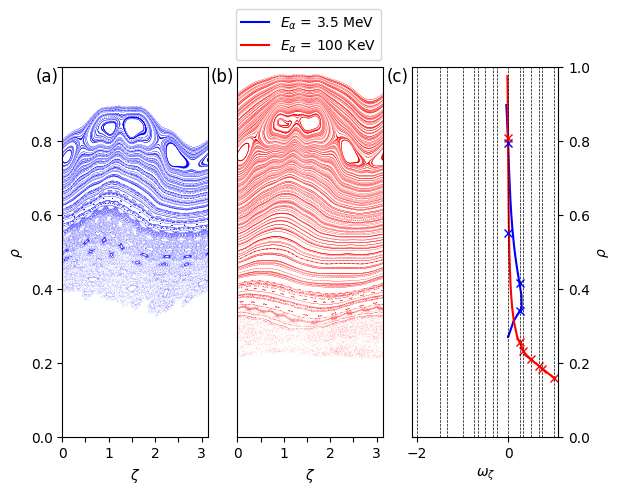

In [6]:
fig,ax = plt.subplots(nrows=1,ncols=3)

# Poincare_plot plotting
for j in [0,1]:
    ax[j].set_xlabel(r"$\zeta$")
    ax[j].set_ylabel(r"$\rho$")
    # ax[j].set_xlim([0, 2 * np.pi])
    ax[j].set_ylim([0, 1])
    if j==0:
        c='b'
    elif j==1:
        c='r'
    eta_points = []
    s_points = []
    for i in range(len(etas_all[j])):
        ax[j].scatter(
            np.array(etas_all[j][i],dtype=float),
            np.array(s_all[j][i],dtype=float),
            marker="o",
            s=0.035,
            c=c,
            edgecolors="none",
            rasterized=True
        )

ax[2].plot(omega_zetas[0],s_profs[0]**0.5,'b',label=r"$E_{\alpha}$ = $3.5$ MeV")
ax[2].plot(omega_zetas[1],s_profs[1]**0.5,'r',label=r"$E_{\alpha}$ = $100$ KeV")
ax[2].set_xlabel(r'$\omega_{\zeta}$')
ax[2].yaxis.set_label_position("right")
ax[2].yaxis.tick_right()
ax[2].set_ylabel(r'$\rho$')
ax[2].set_ylim(0.0,1.0)
ax[2].set_xlim(-2.1,1.1)
ax[2].legend(loc='upper left',bbox_to_anchor=(-1.26, 1.175))
ax[0].set_xlim([0,2*np.pi])
ax[1].set_xlim([0,2*np.pi])
ax[0].set_xticks([0, 1, 2, 3,4,5,6])
ax[0].set_xticklabels([str(0), '',str(1),'', str(2), '',str(3)])
ax[1].set_xticks([0, 1, 2, 3,4,5,6])
ax[1].set_xticklabels([str(0), '',str(1),'', str(2), '',str(3)])
colors_plot = ['bx','rx']
# m=0
for res in res_arr:
    ax[2].plot([res,res],[0,1],'k--',lw=0.5)
    i=0
    for omega_zeta in omega_zetas: # loop through each energy
        # zero_cross = 999999999
        # zero_cross_s = 0
        for j in range(0,len(s_profs[i])-1): # loop through each s
            res_dist_curr = omega_zeta[j] - res
            res_dist_next = omega_zeta[j+1] - res
            if np.sign(res_dist_curr)==np.sign(res_dist_next):
                continue # no res crossing found
            else: # res crossing found
                xs=np.linspace(omega_zeta[j],omega_zeta[j+1],100)
                ses = np.linspace(s_profs[i][j]**0.5,s_profs[i][j+1]**0.5,100)
                x_plot=999999999
                k_plot=0
                k=0
                for x in xs:
                    if abs(x-res) < abs(x_plot-res):
                        x_plot = x
                        k_plot = k
                    k+=1
                ax[2].plot(x_plot,ses[k_plot],colors_plot[i])
            # if abs(omega_zeta[j]) < zero_cross and m==0:
            #     zero_cross = omega_zeta[j]
            #     zero_cross_s = s_profs[i][j]
        i+=1
    # m+=1
ax[2].plot(0,0.55,'bx')

# Extra for Poincare Plot 1
ax[1].yaxis.set_visible(False)

# Add a b and c labels
labels = [item.get_text() for item in ax[0].get_yticklabels()]
labels[-1]=''
ax[0].set_yticklabels(labels)
labels = ['(a)', '(b)', '(c)']

for i, a in enumerate(ax):
    # a.plot([0, 1], [i, i+1])
    # Add label in upper left corner of each subplot
    # if i==0:
    #     a.text(
    #         -0.425, 1, labels[i],
    #         transform=a.transAxes,  # use axes coordinates (0–1)
    #         fontsize=12,
    #         # fontweight='bold',
    #         va='top', ha='left'
    #     )
    # else:
    a.text(
        -0.18, 1, labels[i],
        transform=a.transAxes,  # use axes coordinates (0–1)
        fontsize=12,
        # fontweight='bold',
        va='top', ha='left'
    )


# plt.savefig("poincare_omega_Thea_FORPUBLISH.pdf")
# plt.savefig("poincare_omega_Thea_FORPUBLISH.png")